In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("energy_preprocessed.csv")

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Windspeed,Visibility,Tdewpoint,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,7.000000,63.000000,5.3,2016,1,11,17,0,0,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,6.666667,59.166667,5.2,2016,1,11,17,10,0,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,6.333333,55.333333,5.1,2016,1,11,17,20,0,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,6.000000,51.500000,5.0,2016,1,11,17,30,0,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,5.666667,47.666667,4.9,2016,1,11,17,40,0,0


## Date & Time Feature Engineering

During the preprocessing phase (Task 1), the original `date` column was transformed into several numerical features:

- Year
- Month
- Day
- Hour
- Minute
- DayOfWeek
- IsWeekend

These engineered features allow the machine learning model to capture temporal patterns in appliance energy consumption. For example, energy usage may vary depending on the hour of the day, the day of the week, or whether it is a weekend. Converting the original date into these numerical features makes the information more useful for predictive modeling.

In [6]:
df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'IsWeekend']].head()

,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,2016,1,11,17,0,0,0
1,2016,1,11,17,10,0,0
2,2016,1,11,17,20,0,0
3,2016,1,11,17,30,0,0
4,2016,1,11,17,40,0,0


## Feature Transformation

Feature transformation was completed during the preprocessing phase using feature scaling.

Since the dataset contains numerical variables with different ranges (such as temperature, humidity, pressure, and wind speed), scaling was applied to bring all features onto a comparable scale.

This improves model performance and prevents features with larger numerical values from dominating the learning process.

No additional feature transformation is required for this dataset.

In [7]:
print("Number of Features:",len(df.columns))

df.columns.tolist()

Number of Features: 33


['Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'Year',
 'Month',
 'Day',
 'Hour',
 'Minute',
 'DayOfWeek',
 'IsWeekend']

The dataset was reviewed to ensure that only relevant features remain after preprocessing.

Previously, the random variables `rv1` and `rv2` were removed because they do not contribute meaningful information for predicting appliance energy consumption.

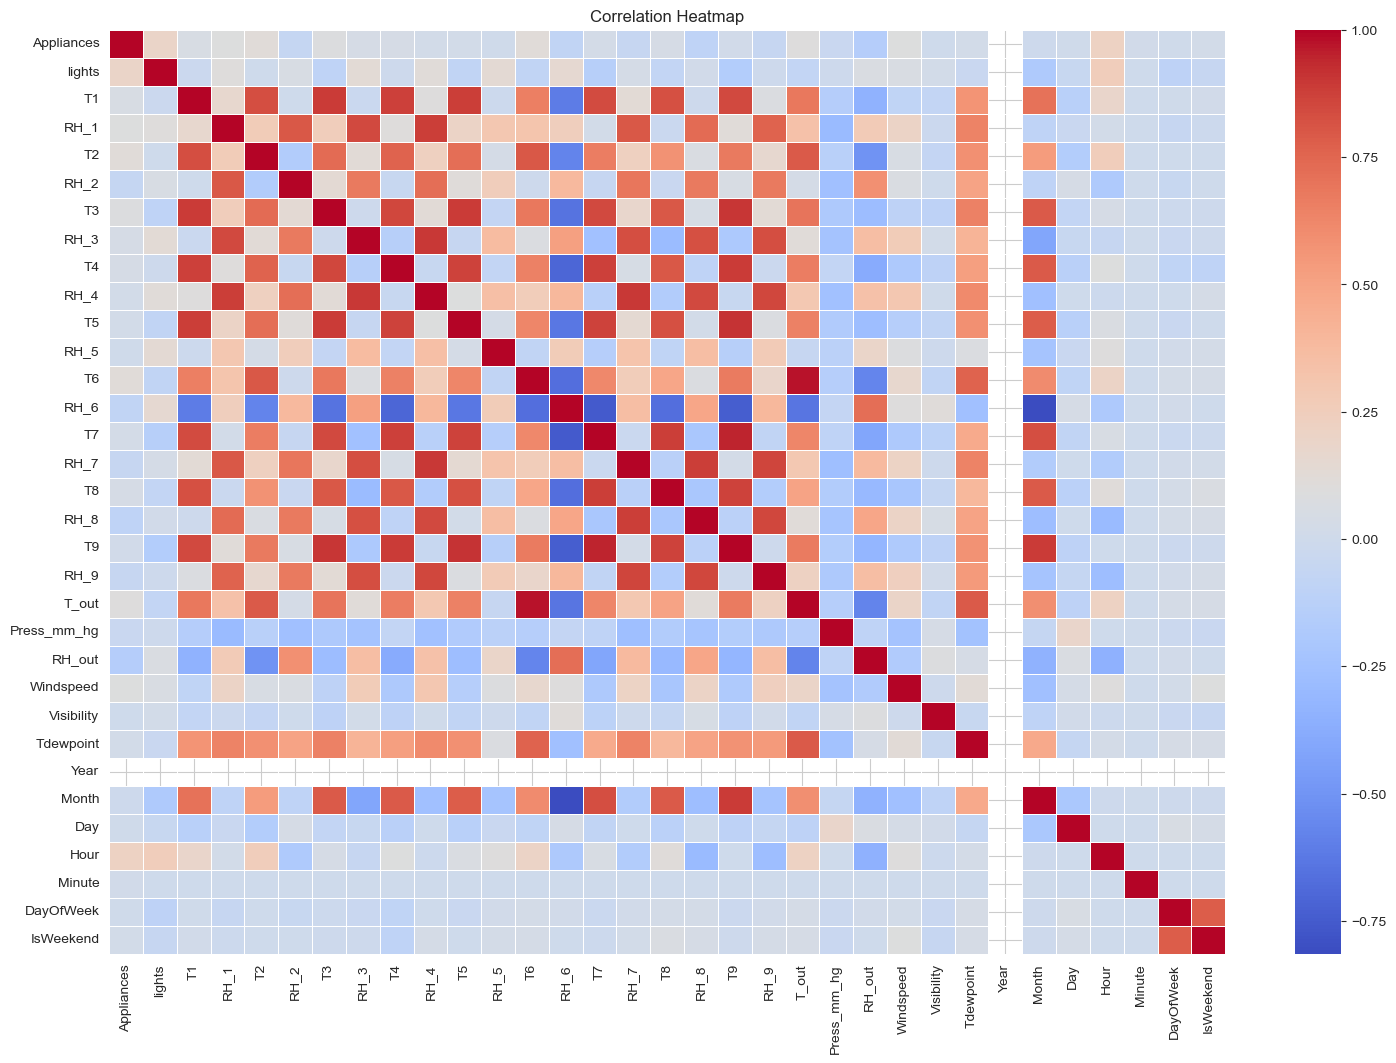

In [9]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The correlation heatmap illustrates the strength and direction of relationships between numerical features.

Highly correlated features may contain redundant information and can be considered for removal if necessary.

It also helps identify which variables have stronger relationships with the target variable (`Appliances`).

In [10]:
X = df.drop("Appliances", axis=1)

selector = VarianceThreshold(threshold=0.01)

selector.fit(X)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")

print(selected_features)

Selected Features:
Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint',
       'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'IsWeekend'],
      dtype='object')


### Interpretation

Variance Threshold removes features with extremely low variance.

Features that show almost no variation across observations contribute little information to the prediction process.

The selected features have sufficient variability and are retained for further analysis.

In [11]:
X = df.drop("Appliances", axis=1)

y = df["Appliances"]

mi_scores = mutual_info_regression(X, y)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)

Hour           0.285744
T9             0.127503
T5             0.115360
T3             0.110634
RH_6           0.109940
T8             0.108000
T4             0.107378
T7             0.101624
T1             0.094202
RH_1           0.088484
T2             0.087643
T6             0.085024
Press_mm_hg    0.081481
RH_5           0.079788
RH_8           0.078955
RH_3           0.075698
RH_4           0.072422
RH_9           0.071270
RH_7           0.067694
T_out          0.067571
RH_2           0.066946
RH_out         0.058431
lights         0.053477
Month          0.048608
Tdewpoint      0.037384
Visibility     0.030007
Windspeed      0.028210
Day            0.024090
DayOfWeek      0.018306
Minute         0.016248
Year           0.013898
IsWeekend      0.010231
dtype: float64


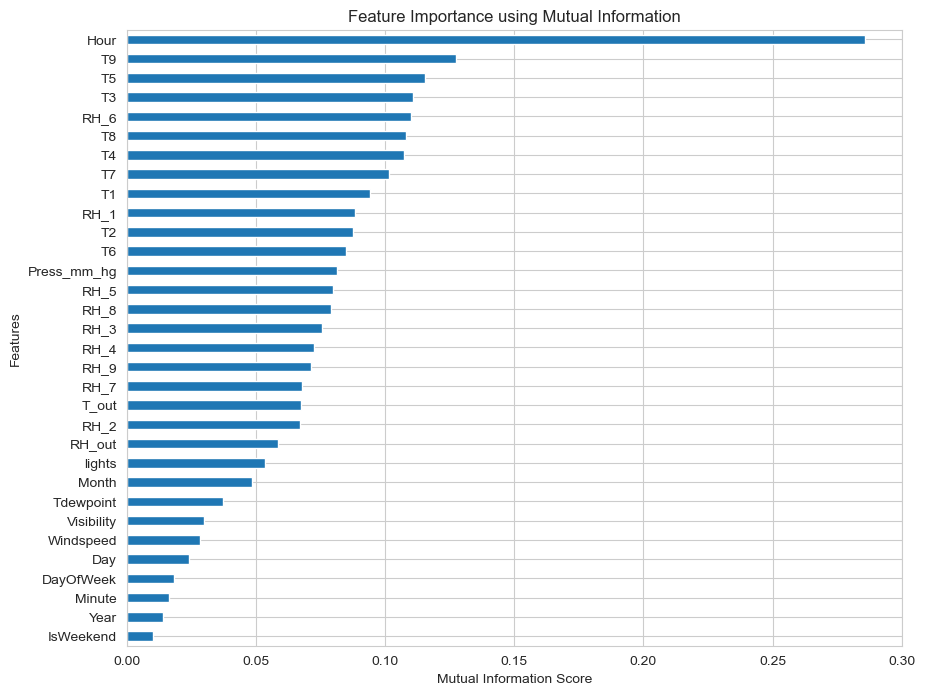

In [12]:
plt.figure(figsize=(10,8))

mi_scores.sort_values().plot(kind="barh")

plt.title("Feature Importance using Mutual Information")

plt.xlabel("Mutual Information Score")

plt.ylabel("Features")

plt.show()

### Interpretation

Mutual Information measures how much information each feature provides about the target variable.

Features with higher scores contribute more to predicting appliance energy consumption, while features with very low scores have less predictive power.

This analysis helps identify the most informative features for future machine learning models.

## Feature Engineering Summary

The following feature engineering techniques were applied:

- Date and time feature extraction (completed during preprocessing)
- Feature transformation through feature scaling (completed during preprocessing)
- Removal of irrelevant features (`rv1` and `rv2`)
- Correlation analysis for identifying relationships among features
- Variance Threshold for removing low-variance features
- Mutual Information analysis for evaluating feature importance

Since the dataset contains only numerical features and no text attributes, text feature extraction was not applicable.

In [14]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (19735, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 33 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Windspeed,Visibility,Tdewpoint,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.0,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,4.039752,38.330834,3.760707,2016.0,3.101647,16.057411,11.502002,24.998733,2.977249,0.277274
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.451221,11.794719,4.194648,0.0,1.339200,8.450998,6.921953,17.079178,1.985617,0.447664
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,0.000000,1.000000,-6.600000,2016.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,2.000000,29.000000,0.900000,2016.0,2.000000,9.000000,6.000000,10.000000,1.000000,0.000000
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,3.666667,40.000000,3.433333,2016.0,3.000000,16.000000,12.000000,20.000000,3.000000,0.000000
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,5.500000,40.000000,6.566667,2016.0,4.000000,23.000000,17.000000,40.000000,5.000000,1.000000
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,14.000000,66.000000,15.500000,2016.0,5.000000,31.000000,23.000000,50.000000,6.000000,1.000000


## Dataset Overview

Before visualization, the dataset was examined to understand its dimensions, data types, and statistical summary.

The dataset consists primarily of numerical features, making it suitable for regression analysis and exploratory data visualization.

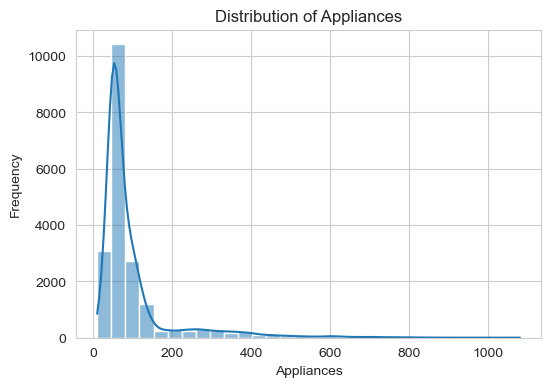

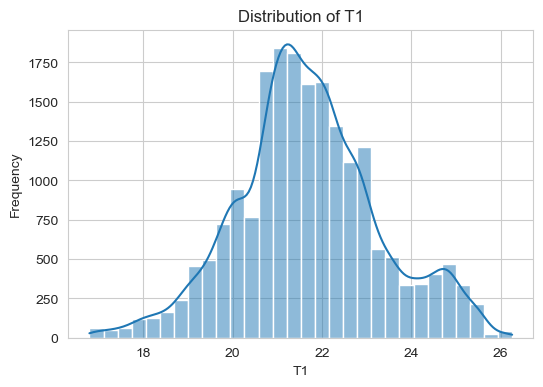

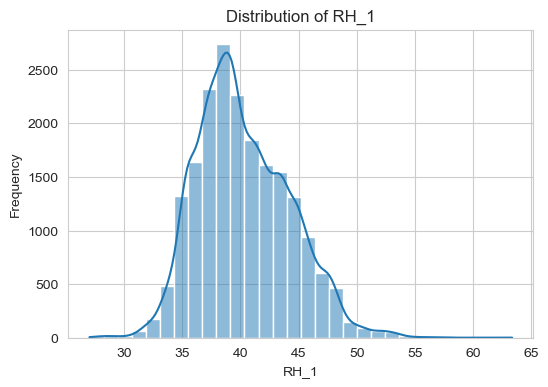

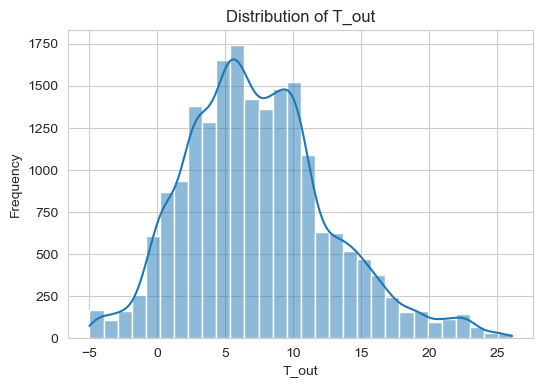

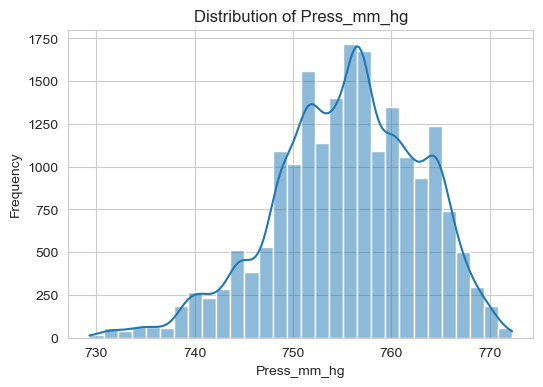

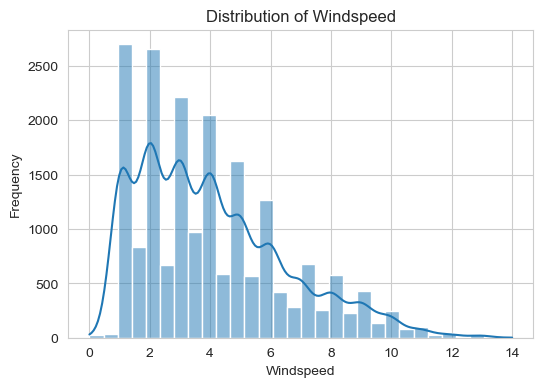

In [15]:
numerical_features = [
    'Appliances',
    'T1',
    'RH_1',
    'T_out',
    'Press_mm_hg',
    'Windspeed'
]

for feature in numerical_features:
    plt.figure(figsize=(6,4))

    sns.histplot(df[feature], bins=30, kde=True)

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.show()

### Interpretation

The histograms show how the values of each numerical feature are distributed.

Some variables follow an approximately normal distribution, while others are skewed. Understanding these distributions helps identify unusual patterns, skewness, and potential outliers that may affect model performance.

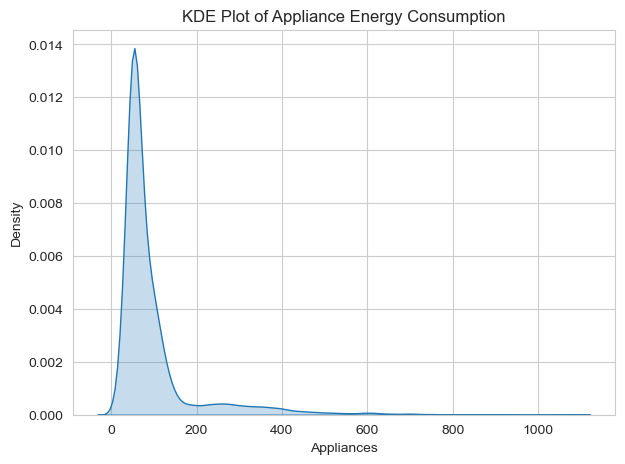

In [16]:
plt.figure(figsize=(7,5))

sns.kdeplot(df['Appliances'], fill=True)

plt.title("KDE Plot of Appliance Energy Consumption")

plt.xlabel("Appliances")

plt.ylabel("Density")

plt.show()

### Interpretation

The KDE plot provides a smooth estimate of the distribution of appliance energy consumption. It helps identify where most observations are concentrated without relying on histogram bins.

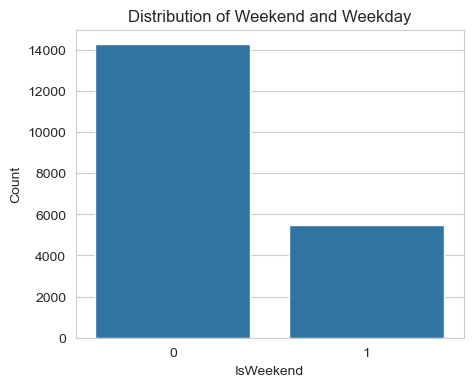

In [30]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='IsWeekend')
plt.title('Distribution of Weekend and Weekday')
plt.xlabel('IsWeekend')
plt.ylabel('Count')
plt.show()

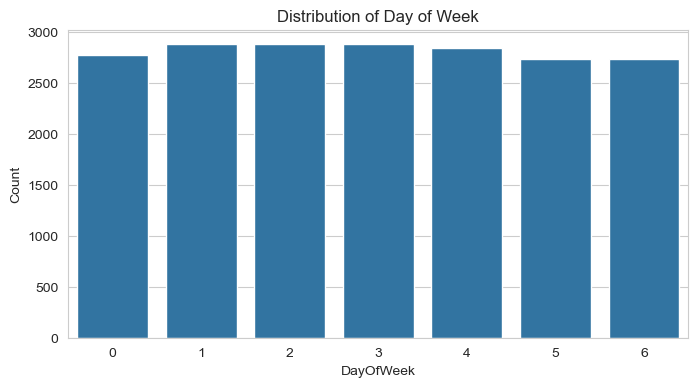

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='DayOfWeek')
plt.title('Distribution of Day of Week')
plt.xlabel('DayOfWeek')
plt.ylabel('Count')
plt.show()

### Interpretation

The count plots illustrate the frequency distribution of the categorical date-related features, **DayOfWeek** and **IsWeekend**. These visualizations help verify how observations are distributed across different days of the week and between weekdays and weekends. The distributions indicate that the dataset contains observations from all days, ensuring that temporal patterns are adequately represented for further analysis and model development.

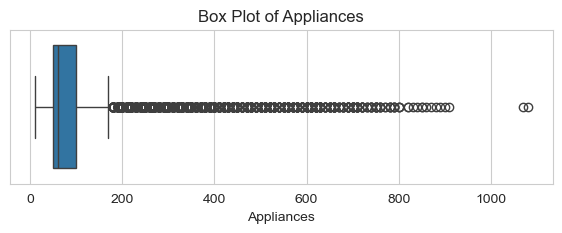

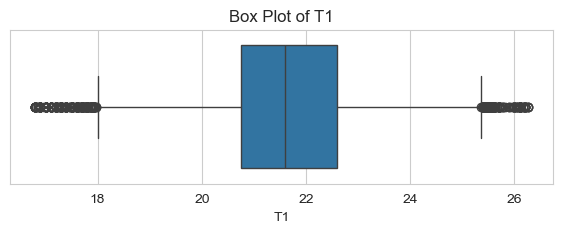

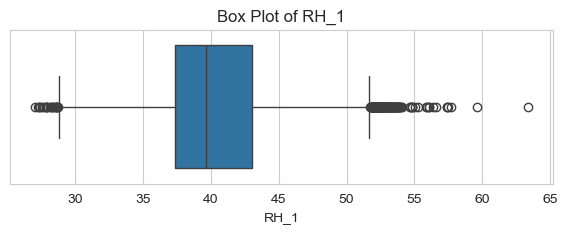

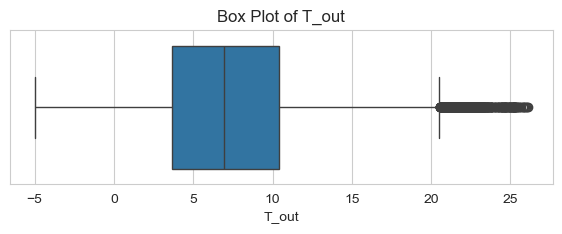

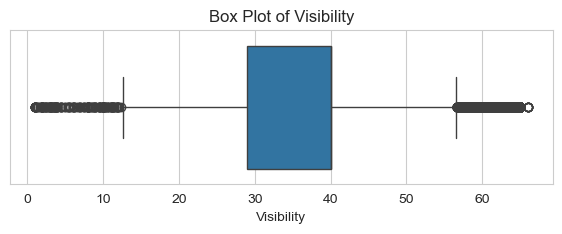

In [27]:
box_features = [
    'Appliances',
    'T1',
    'RH_1',
    'T_out',
    'Visibility'
]

for feature in box_features:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[feature])

    plt.title(f'Box Plot of {feature}')

    plt.xlabel(feature)

    plt.show()

### Interpretation

Box plots help identify the spread of each feature and detect potential outliers.

Several features contain extreme values, which may represent unusual environmental conditions or periods of high appliance energy usage.

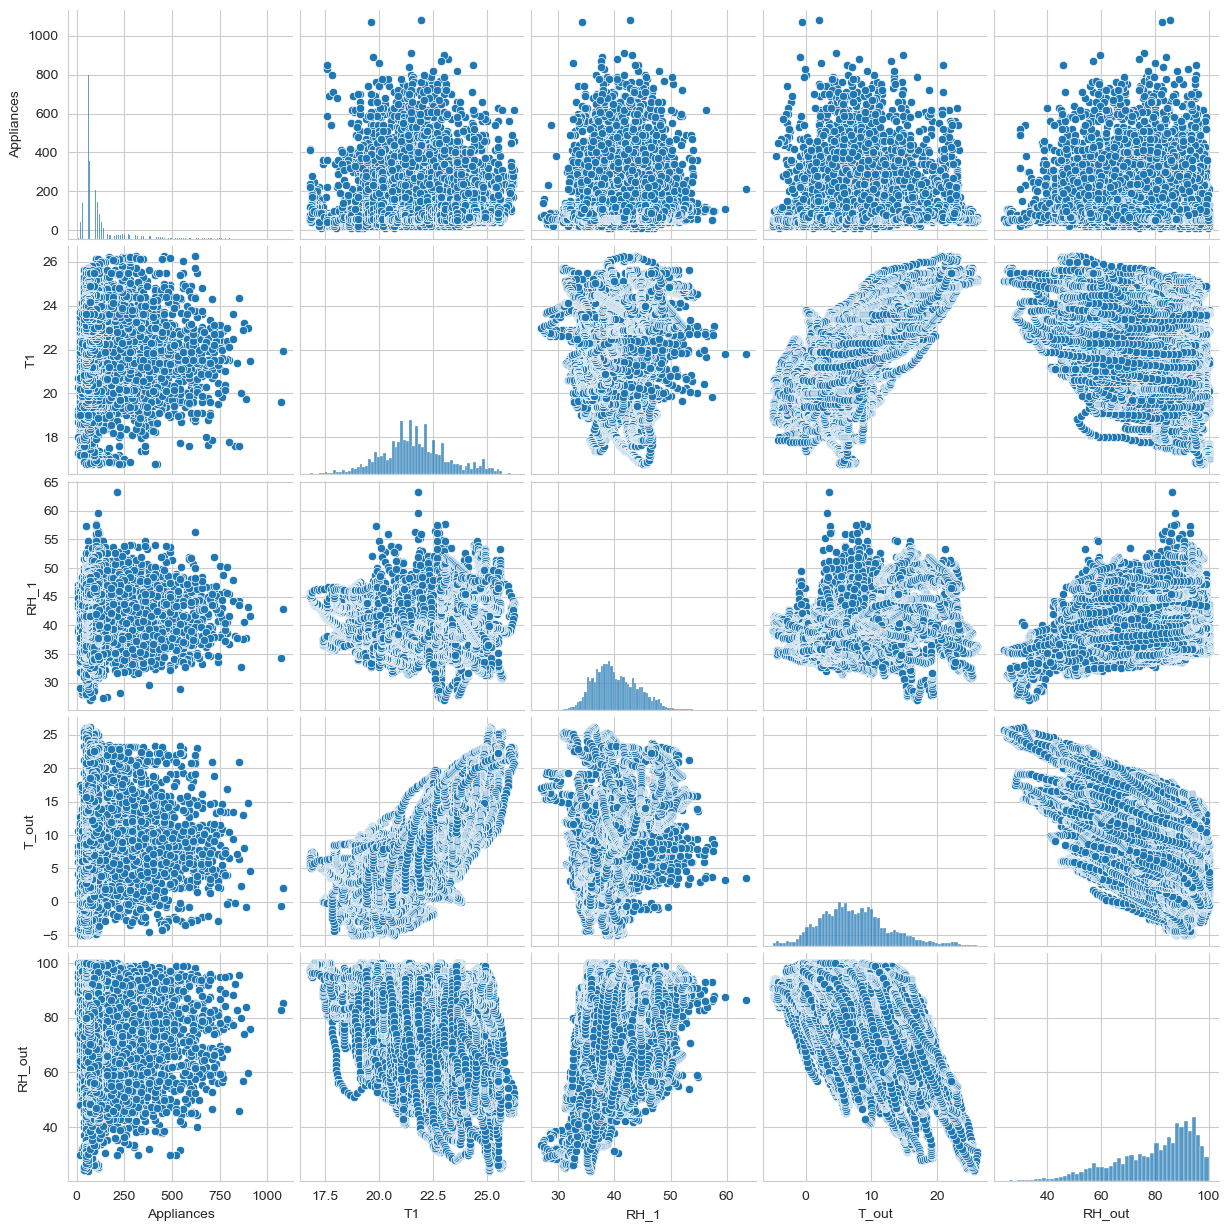

In [19]:
selected_features = [
    'Appliances',
    'T1',
    'RH_1',
    'T_out',
    'RH_out'
]

sns.pairplot(df[selected_features])

plt.show()

### Interpretation

The pair plot visualizes relationships among selected numerical features.

It helps identify trends, clusters, and potential correlations while also showing the distribution of each feature along the diagonal.

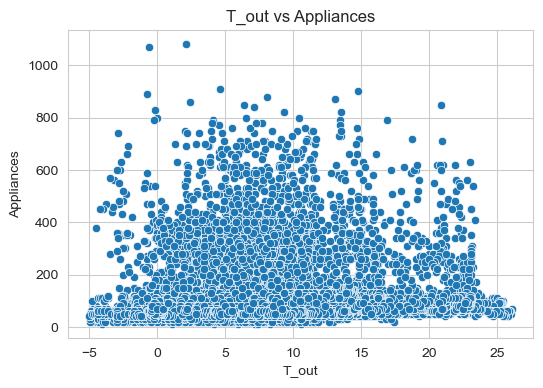

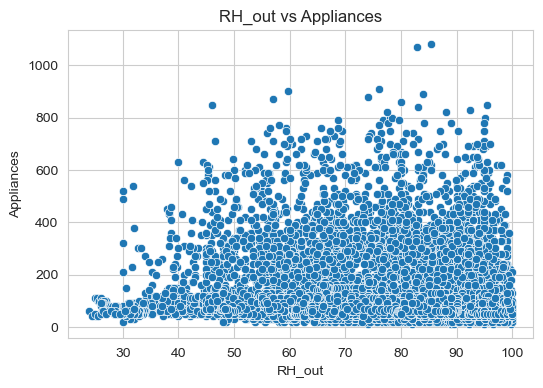

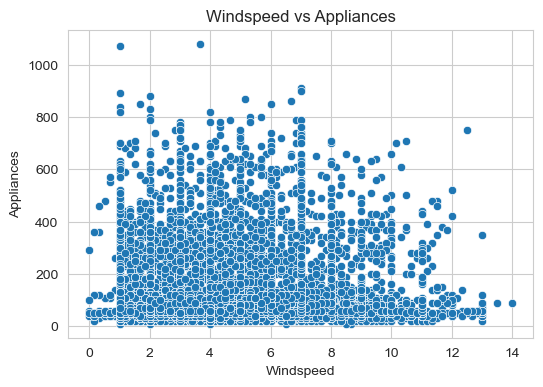

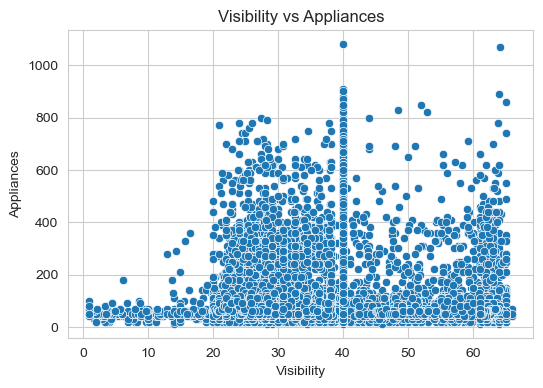

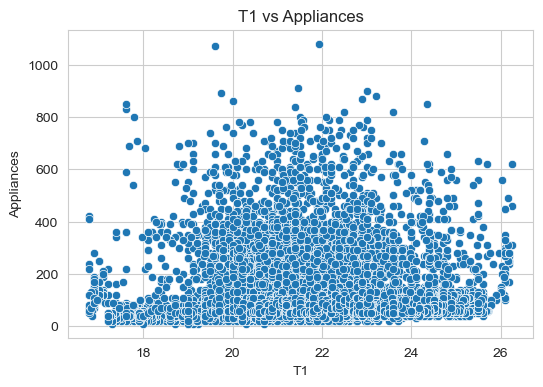

In [21]:
scatter_features = [
    'T_out',
    'RH_out',
    'Windspeed',
    'Visibility',
    'T1'
]

for feature in scatter_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=feature,
        y='Appliances'
    )

    plt.title(f'{feature} vs Appliances')

    plt.xlabel(feature)

    plt.ylabel('Appliances')

    plt.show()

### Interpretation

Scatter plots show the relationship between each feature and appliance energy consumption.

Most relationships appear weak to moderate, suggesting that appliance energy usage is influenced by multiple variables rather than a single feature.

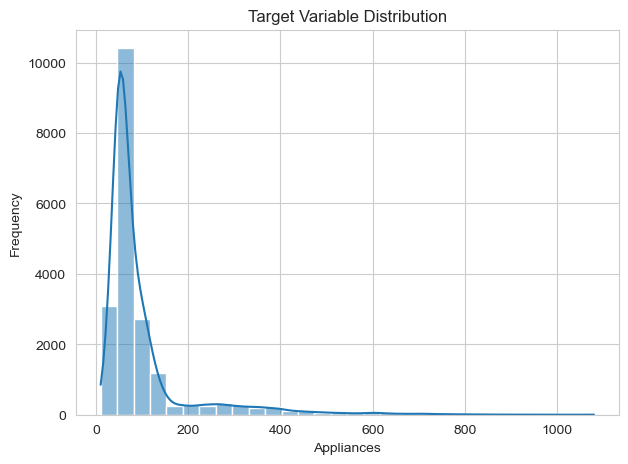

In [22]:
plt.figure(figsize=(7,5))

sns.histplot(df['Appliances'], bins=30, kde=True)

plt.title("Target Variable Distribution")

plt.xlabel("Appliances")

plt.ylabel("Frequency")

plt.show()

### Interpretation

The target variable distribution illustrates how appliance energy consumption values are spread across the dataset.

Most observations are concentrated within a lower range of energy consumption, while a smaller number of observations represent higher consumption levels.

## Non-Applicable Techniques

Some techniques mentioned in the project requirements were not applicable to this dataset:

- **Text Feature Extraction:** Not applicable because the dataset contains only numerical and date-related features. There are no text attributes to process.

- **Class-wise Comparison Plots:** Not applicable because this is a **regression** problem. The target variable (`Appliances`) is continuous rather than categorical, so there are no classes to compare.

These techniques were therefore not included in the analysis.

# Conclusion

In this task, feature engineering and exploratory data analysis (EDA) were performed on the Appliances Energy Prediction dataset to improve data quality and gain meaningful insights before model development.

During the feature engineering phase, previously created date and time features were reviewed, feature transformation completed during preprocessing was acknowledged, and feature selection techniques such as Correlation Analysis, Variance Threshold, and Mutual Information were applied to evaluate the relevance of the features. Feature importance analysis identified the variables that contribute most to predicting appliance energy consumption.

In the EDA phase, various visualizations including histograms, KDE plots, count plots, box plots, scatter plots, pair plots, and a correlation heatmap were used to understand the distribution of features, detect outliers, examine relationships among variables, and analyze the target variable. The analysis revealed that several temperature and humidity features are highly correlated, while appliance energy consumption is influenced by multiple factors rather than a single feature. Although outliers were identified in several numerical variables, they were retained because they represent valid real-world sensor measurements rather than data errors.

Overall, the dataset is well-prepared for the next phase of the project, which involves building, training, and evaluating machine learning models for predicting appliance energy consumption.